# Eksperimen SML - Izza
## Dataset: Bank Marketing (UCI)
Eksperimen ini mencakup Data Loading, EDA, Preprocessing, dan Training model.

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import urllib.request, zipfile, io
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully')

Libraries imported successfully


## 2. Data Loading

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip'
r = urllib.request.urlopen(url)
z = zipfile.ZipFile(io.BytesIO(r.read()))
df = pd.read_csv(z.open('bank.csv'), sep=';')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (4521, 17)

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## 3. Exploratory Data Analysis (EDA)

In [3]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [4]:
print('=== Statistik Deskriptif ===')
df.describe()

=== Statistik Deskriptif ===


,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [5]:
print('=== Missing Values ===')
print(df.isnull().sum())

=== Missing Values ===
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


=== Distribusi Target ===
y
no     4000
yes     521
Name: count, dtype: int64


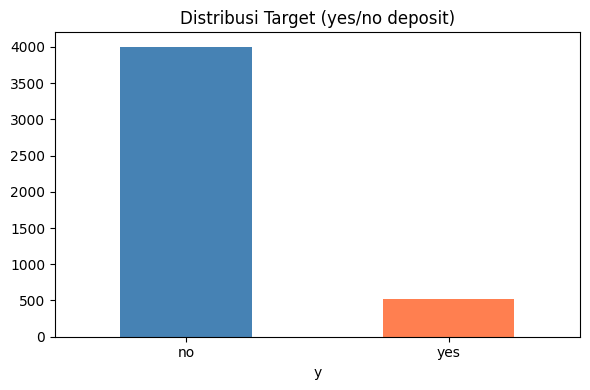

In [6]:
print('=== Distribusi Target ===')
print(df['y'].value_counts())

plt.figure(figsize=(6,4))
df['y'].value_counts().plot(kind='bar', color=['steelblue','coral'])
plt.title('Distribusi Target (yes/no deposit)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('distribusi_kelas.png')
plt.show()

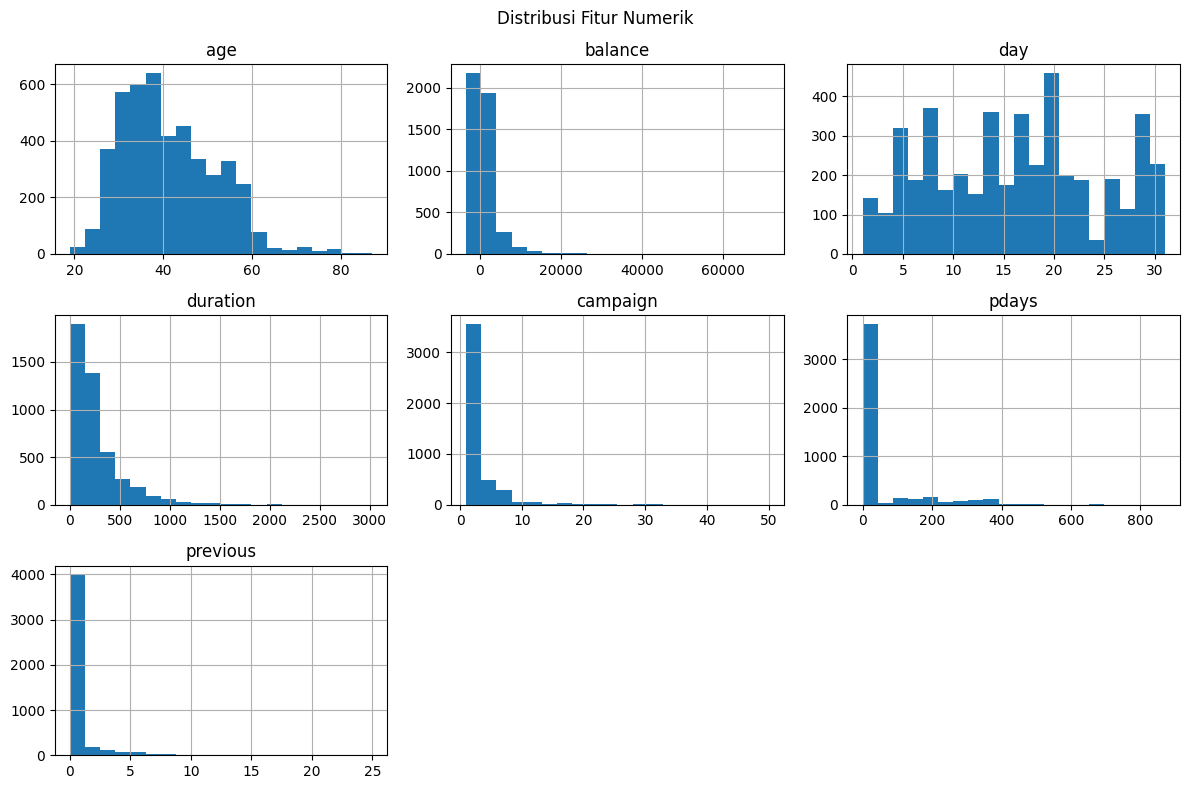

In [7]:
# Distribusi fitur numerik
num_cols = df.select_dtypes(include='number').columns
df[num_cols].hist(figsize=(12,8), bins=20)
plt.suptitle('Distribusi Fitur Numerik')
plt.tight_layout()
plt.savefig('distribusi_fitur.png')
plt.show()

## 4. Preprocessing & Ekstraksi Fitur

In [8]:
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('y')
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
df['y'] = (df['y'] == 'yes').astype(int)

X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

import os
os.makedirs('bank_preprocessing', exist_ok=True)
train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
train_df['target'] = y_train.values
test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
test_df['target'] = y_test.values
train_df.to_csv('bank_preprocessing/train.csv', index=False)
test_df.to_csv('bank_preprocessing/test.csv', index=False)

print(f'X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}')
print('Preprocessing selesai.')

X_train: (3616, 16), X_test: (905, 16)
Preprocessing selesai.


## 5. Training Model

In [9]:
model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42
)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f'Accuracy: {acc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No','Yes']))

Accuracy: 0.8851

Classification Report:
              precision    recall  f1-score   support

          No       0.92      0.95      0.94       801
         Yes       0.50      0.36      0.42       104

    accuracy                           0.89       905
   macro avg       0.71      0.65      0.68       905
weighted avg       0.87      0.89      0.88       905



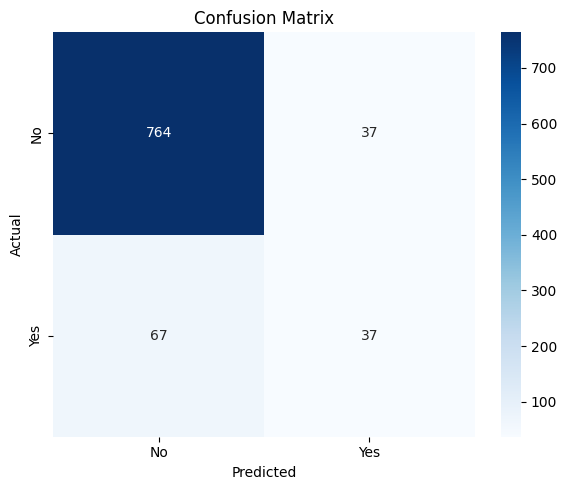

Eksperimen selesai!


In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print('Eksperimen selesai!')